In [110]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from sklearn.model_selection import train_test_split
df=pd.read_csv("diabetes_data_.csv")
df

,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory
0,1,69,Male,34.6,61.0,89.0,87.0,30.0,1.498,Medium,No,High,No
1,2,32,Female,21.8,95.0,NaN,102.0,27.0,0.672,Low,Yes,High,Yes
2,3,78,Female,31.7,64.0,70.0,75.0,13.0,0.980,Medium,Yes,Moderate,Yes
3,4,38,Female,21.7,83.0,135.0,158.0,26.0,1.239,Medium,Yes,Low,No
4,5,41,Male,24.3,71.0,131.0,NaN,12.0,0.425,Low,No,High,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,21,Female,32.9,82.0,118.0,93.0,16.0,0.252,Low,Yes,High,No
996,997,43,Female,30.3,67.0,62.0,141.0,18.0,0.271,Low,No,High,Yes
997,998,75,Male,22.6,85.0,88.0,115.0,28.0,1.222,Medium,No,High,Yes
998,999,46,Female,22.8,95.0,162.0,102.0,11.0,1.239,Low,Yes,Low,No


In [111]:
df.describe()

,PatientID,Age,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction
count,1000.000000,1000.0000,950.000000,950.000000,950.000000,950.000000,950.000000,1000.000000
mean,500.500000,50.6760,29.439789,75.153684,118.180000,88.131579,24.390526,1.014870
std,288.819436,19.7803,11.861813,11.997522,53.172465,49.906283,12.174448,0.538884
min,1.000000,18.0000,9.900000,39.000000,12.000000,-69.000000,-10.000000,0.100000
25%,250.750000,34.0000,24.300000,67.000000,89.000000,56.000000,16.000000,0.550250
50%,500.500000,50.0000,28.300000,75.000000,115.000000,90.000000,24.000000,0.969000
75%,750.250000,68.0000,32.300000,83.000000,139.000000,122.000000,32.000000,1.465250
max,1000.000000,84.0000,145.800000,122.000000,592.000000,246.000000,62.000000,1.992000


In [112]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
df.info()

Shape: (1000, 13)

Columns:
 Index(['PatientID', 'Age', 'Gender', 'BMI', 'BloodPressure', 'GlucoseLevel',
       'Insulin', 'SkinThickness', 'DiabetesPedigreeFunction',
       'PhysicalActivity', 'Smoking', 'Alcohol_Intake', 'FamilyHistory'],
      dtype='str')

Info:

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 1000 non-null   int64  
 1   Age                       1000 non-null   int64  
 2   Gender                    1000 non-null   str    
 3   BMI                       950 non-null    float64
 4   BloodPressure             950 non-null    float64
 5   GlucoseLevel              950 non-null    float64
 6   Insulin                   950 non-null    float64
 7   SkinThickness             950 non-null    float64
 8   DiabetesPedigreeFunction  1000 non-null   float64
 9   PhysicalActivity         

In [113]:
df.tail()

,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory
995,996,21,Female,32.9,82.0,118.0,93.0,16.0,0.252,Low,Yes,High,No
996,997,43,Female,30.3,67.0,62.0,141.0,18.0,0.271,Low,No,High,Yes
997,998,75,Male,22.6,85.0,88.0,115.0,28.0,1.222,Medium,No,High,Yes
998,999,46,Female,22.8,95.0,162.0,102.0,11.0,1.239,Low,Yes,Low,No
999,1000,54,Female,NaN,88.0,146.0,94.0,29.0,0.896,Low,Yes,Moderate,No


In [114]:
df.head()

,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory
0,1,69,Male,34.6,61.0,89.0,87.0,30.0,1.498,Medium,No,High,No
1,2,32,Female,21.8,95.0,NaN,102.0,27.0,0.672,Low,Yes,High,Yes
2,3,78,Female,31.7,64.0,70.0,75.0,13.0,0.980,Medium,Yes,Moderate,Yes
3,4,38,Female,21.7,83.0,135.0,158.0,26.0,1.239,Medium,Yes,Low,No
4,5,41,Male,24.3,71.0,131.0,NaN,12.0,0.425,Low,No,High,No


In [115]:
df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
BMI                         50
BloodPressure               50
GlucoseLevel                50
Insulin                     50
SkinThickness               50
DiabetesPedigreeFunction     0
PhysicalActivity             0
Smoking                      0
Alcohol_Intake               0
FamilyHistory                0
dtype: int64

In [116]:
df.duplicated().sum()

np.int64(0)

In [117]:
mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['PhysicalActivity'] = df['PhysicalActivity'].map(mapping)

corr_matrix = df.corr(numeric_only=True)

In [118]:
mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['Alcohol_Intake'] = df['Alcohol_Intake'].map(mapping)

corr_matrix = df.corr(numeric_only=True)

In [119]:
def define_diabetes_status(row):
    if row['GlucoseLevel'] >= 126:
        return 1
    
    if row['GlucoseLevel'] >= 100 and row['BMI'] >= 30:
        return 1
    
    if row['DiabetesPedigreeFunction'] > 1.2 and row['GlucoseLevel'] > 110:
        return 1
    
    if row['Age'] > 60 and row['GlucoseLevel'] > 115:
        return 1
    
    return 0
df['Outcome'] = df.apply(define_diabetes_status, axis=1)

print("Class Distribution:")
print(df['Outcome'].value_counts())


Class Distribution:
Outcome
1    528
0    472
Name: count, dtype: int64


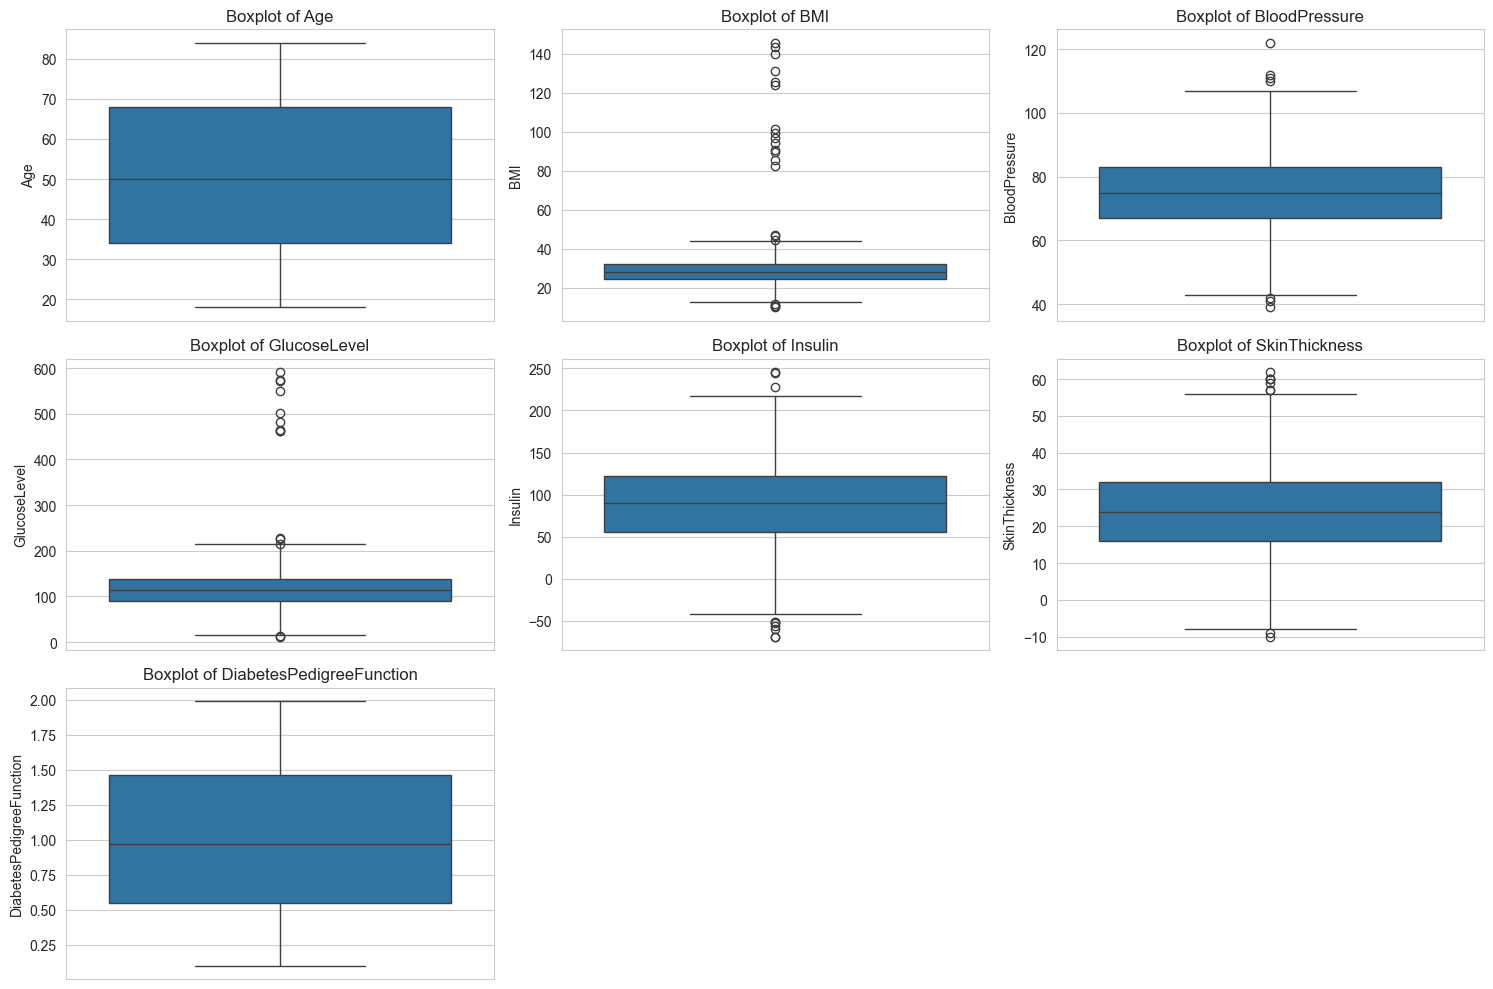

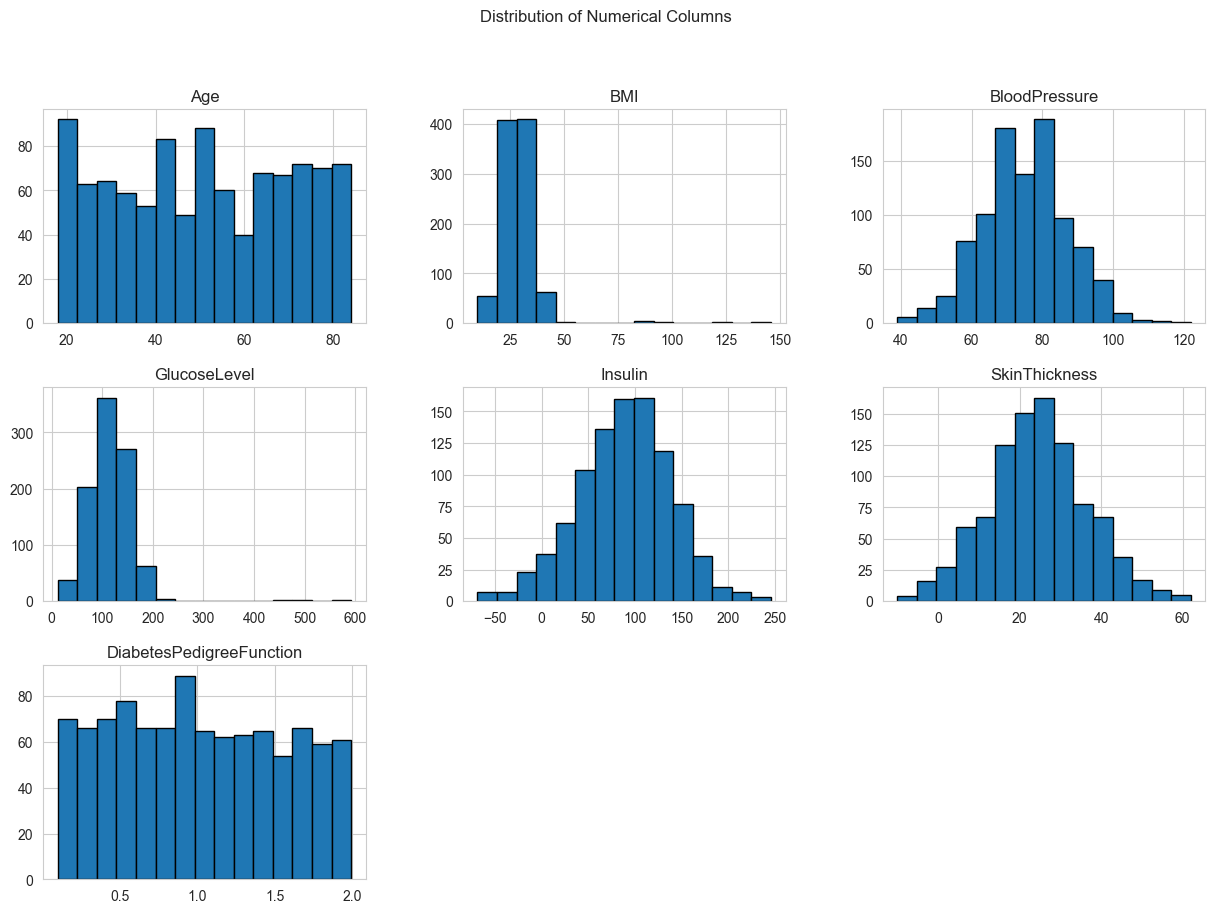

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age', 'BMI', 'BloodPressure', 'GlucoseLevel', 'Insulin', 'SkinThickness', 'DiabetesPedigreeFunction']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

df[num_cols].hist(bins=15, figsize=(15, 10), layout=(3, 3), edgecolor='black')
plt.suptitle('Distribution of Numerical Columns')
plt.show()

In [121]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

insulin_outliers = detect_outliers(df, 'Insulin')
print(f"Total outliers in Insulin: {len(insulin_outliers)}")
print(insulin_outliers)

Total outliers in Insulin: 10
     PatientID  Age  Gender   BMI  BloodPressure  GlucoseLevel  Insulin  \
94          95   61    Male  29.3            NaN         102.0    -60.0   
103        104   26    Male  24.0           79.0         144.0    -53.0   
513        514   71  Female  23.5           76.0         105.0    -52.0   
531        532   80    Male  25.6           88.0         124.0    -56.0   
535        536   30    Male  21.6           80.0         131.0    -52.0   
621        622   21  Female  34.5           75.0           NaN    -69.0   
675        676   74    Male  23.8           81.0         112.0    -69.0   
680        681   30    Male  28.5           69.0         131.0    228.0   
766        767   57  Female  21.4           67.0          66.0    244.0   
893        894   41  Female  22.7           60.0         104.0    246.0   

     SkinThickness  DiabetesPedigreeFunction  PhysicalActivity Smoking  \
94            15.0                     1.251                 2     Yes

In [122]:
num_cols = df.select_dtypes(include=['number']).columns.drop('PatientID')

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Column: {col:20} | Outliers: {len(outliers)}")

Column: Age                  | Outliers: 0
Column: BMI                  | Outliers: 21
Column: BloodPressure        | Outliers: 7
Column: GlucoseLevel         | Outliers: 14
Column: Insulin              | Outliers: 10
Column: SkinThickness        | Outliers: 9
Column: DiabetesPedigreeFunction | Outliers: 0
Column: PhysicalActivity     | Outliers: 0
Column: Alcohol_Intake       | Outliers: 0
Column: Outcome              | Outliers: 0


In [123]:
missing_cols = df.columns[df.isnull().any()]

for col in missing_cols:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PatientID                   0
Age                         0
Gender                      0
BMI                         0
BloodPressure               0
GlucoseLevel                0
Insulin                     0
SkinThickness               0
DiabetesPedigreeFunction    0
PhysicalActivity            0
Smoking                     0
Alcohol_Intake              0
FamilyHistory               0
Outcome                     0
dtype: int64


In [124]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Smoking'] = df['Smoking'].map({'Yes': 1, 'No': 0})
df['FamilyHistory'] = df['FamilyHistory'].map({'Yes': 1, 'No': 0})

print(df[['Gender', 'PhysicalActivity', 'Smoking', 'Alcohol_Intake', 'FamilyHistory']].head())

   Gender  PhysicalActivity  Smoking  Alcohol_Intake  FamilyHistory
0       1                 2        0             3.0              0
1       0                 1        1             3.0              1
2       0                 2        1             1.0              1
3       0                 2        1             1.0              0
4       1                 1        0             3.0              0


In [125]:
print(df.columns.tolist())

['PatientID', 'Age', 'Gender', 'BMI', 'BloodPressure', 'GlucoseLevel', 'Insulin', 'SkinThickness', 'DiabetesPedigreeFunction', 'PhysicalActivity', 'Smoking', 'Alcohol_Intake', 'FamilyHistory', 'Outcome']


In [126]:
df = df.dropna()

print(f"Rows remaining after removing missing values: {len(df)}")

Rows remaining after removing missing values: 1000


In [127]:
df = df.drop_duplicates()

df = df.reset_index(drop=True)

print(f"Final dataset size: {df.shape}")
df.head()

Final dataset size: (1000, 14)


,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory,Outcome
0,1,69,1,34.6,61.0,89.0,87.0,30.0,1.498,2,0,3.0,0,0
1,2,32,0,21.8,95.0,115.0,102.0,27.0,0.672,1,1,3.0,1,0
2,3,78,0,31.7,64.0,70.0,75.0,13.0,0.980,2,1,1.0,1,0
3,4,38,0,21.7,83.0,135.0,158.0,26.0,1.239,2,1,1.0,0,1
4,5,41,1,24.3,71.0,131.0,90.0,12.0,0.425,1,0,3.0,0,1


In [128]:
print(list(df.columns))

['PatientID', 'Age', 'Gender', 'BMI', 'BloodPressure', 'GlucoseLevel', 'Insulin', 'SkinThickness', 'DiabetesPedigreeFunction', 'PhysicalActivity', 'Smoking', 'Alcohol_Intake', 'FamilyHistory', 'Outcome']


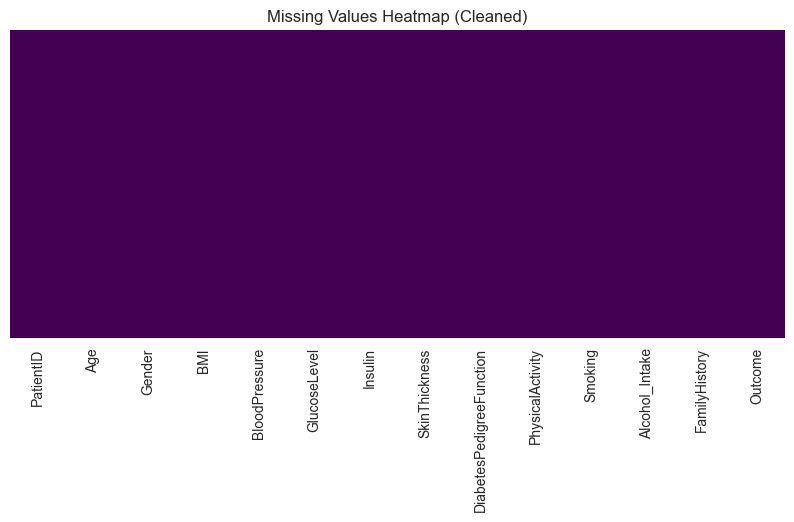

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (Cleaned)")
plt.show()

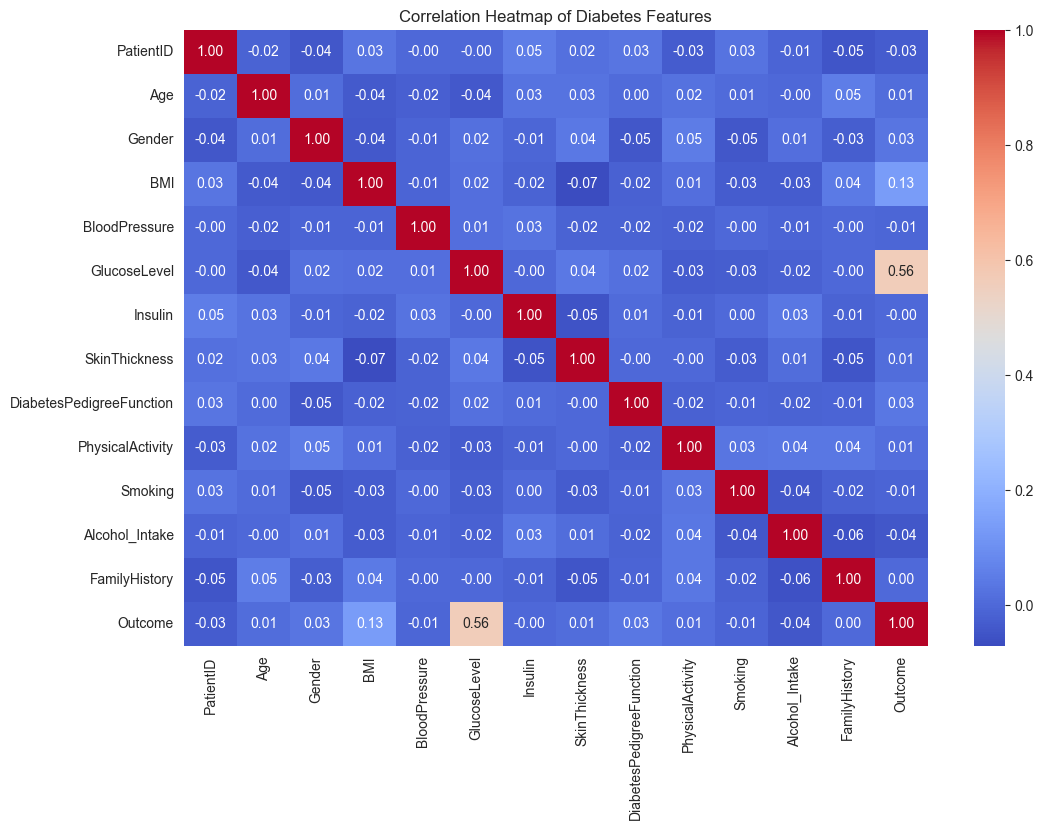

In [130]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Diabetes Features")
plt.show()

In [131]:
num_cols = ['BMI', 'BloodPressure', 'GlucoseLevel', 'Insulin', 'SkinThickness']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers have been handled using capping.")

Outliers have been handled using capping.


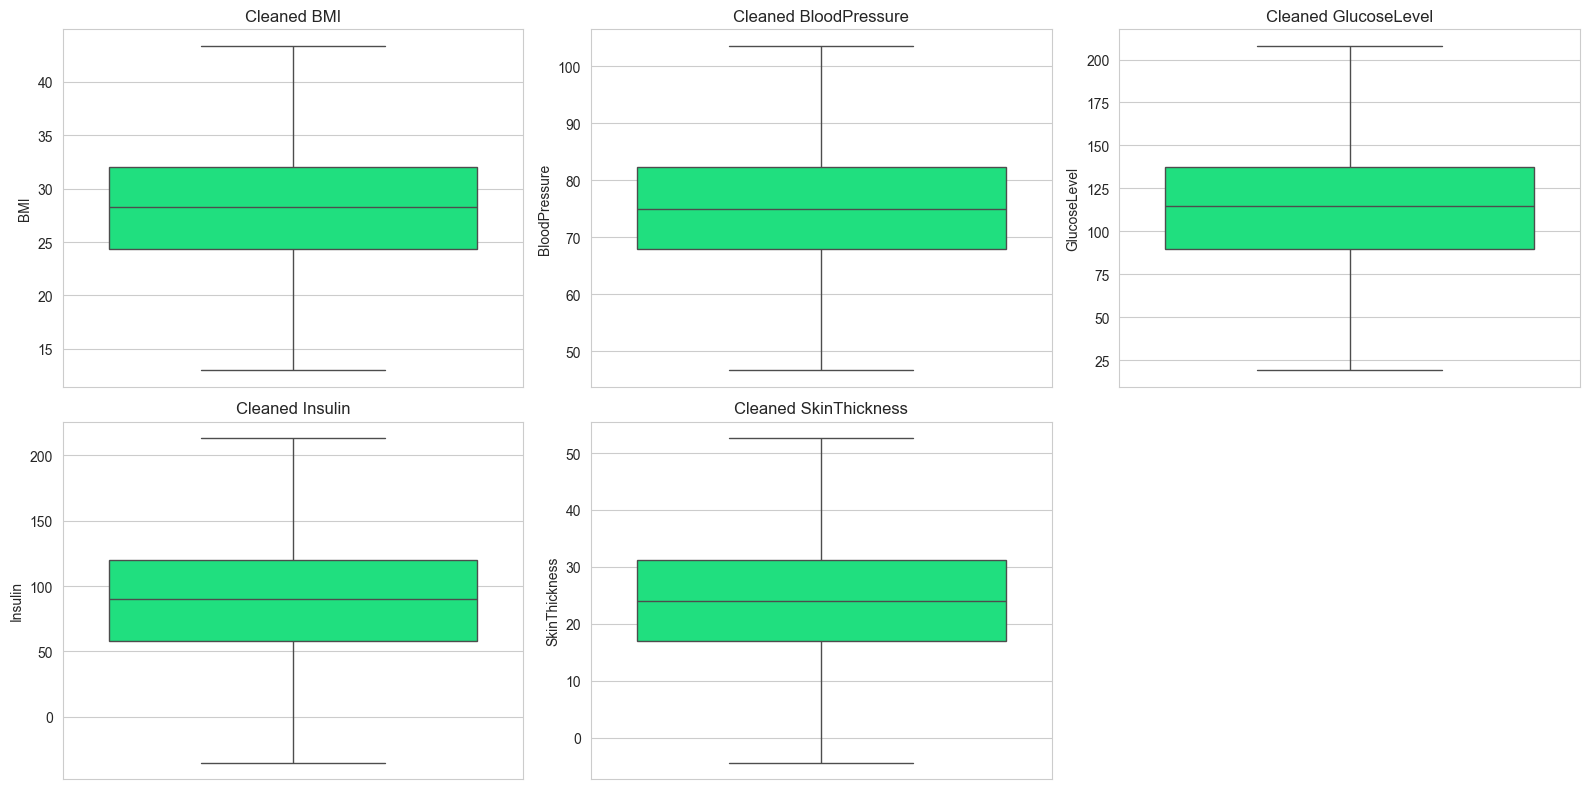

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
cols_to_check = ['BMI', 'BloodPressure', 'GlucoseLevel', 'Insulin', 'SkinThickness']

plt.figure(figsize=(16, 8))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='springgreen')
    plt.title(f'Cleaned {col}')

plt.tight_layout()
plt.show()

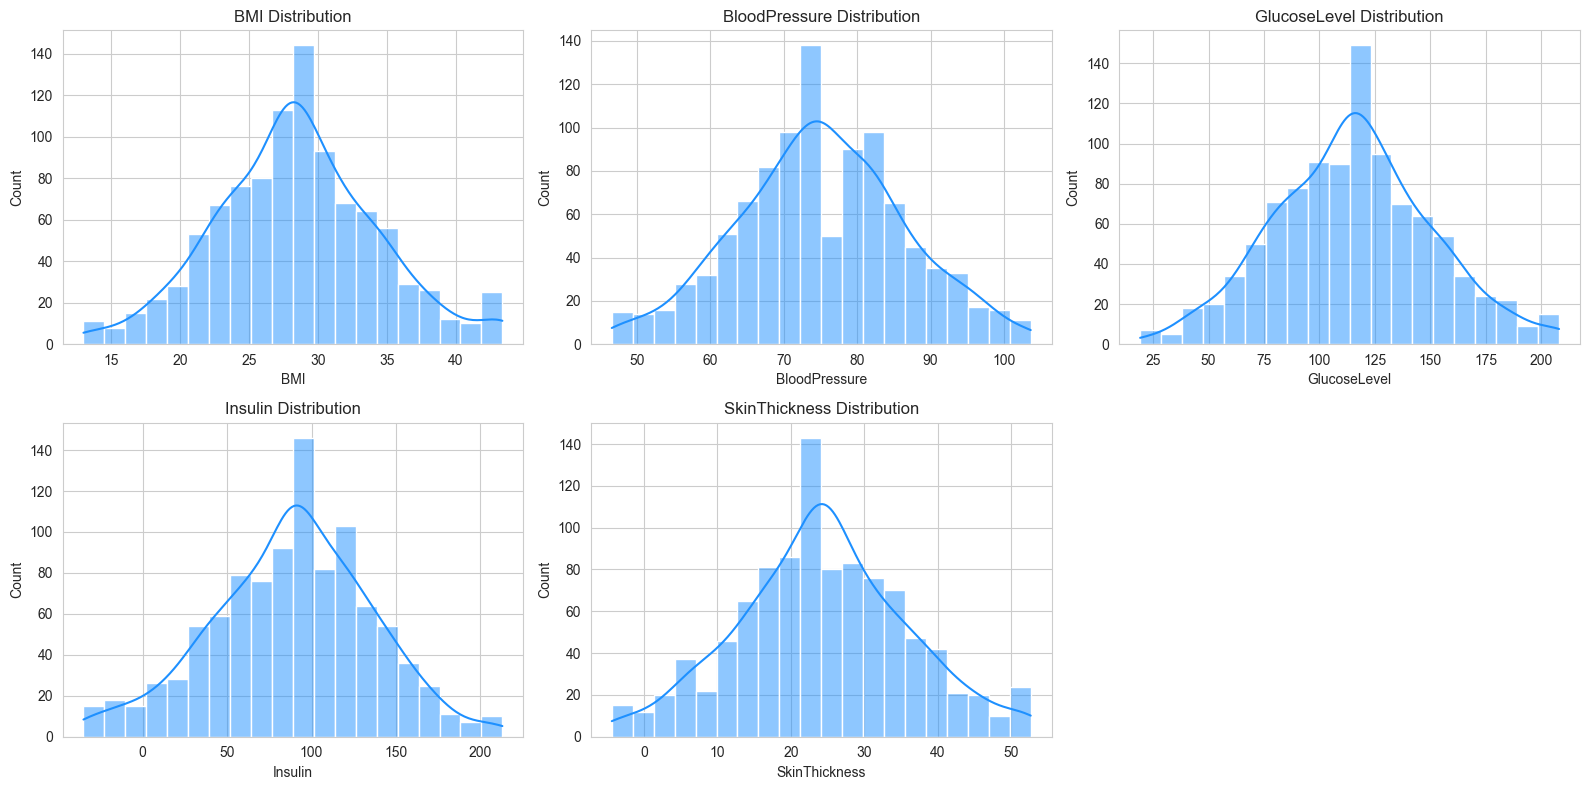

In [133]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='dodgerblue')
    plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()

In [134]:
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    remaining_outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col:15} | Remaining Outliers: {len(remaining_outliers)}")

BMI             | Remaining Outliers: 0
BloodPressure   | Remaining Outliers: 0
GlucoseLevel    | Remaining Outliers: 0
Insulin         | Remaining Outliers: 0
SkinThickness   | Remaining Outliers: 0


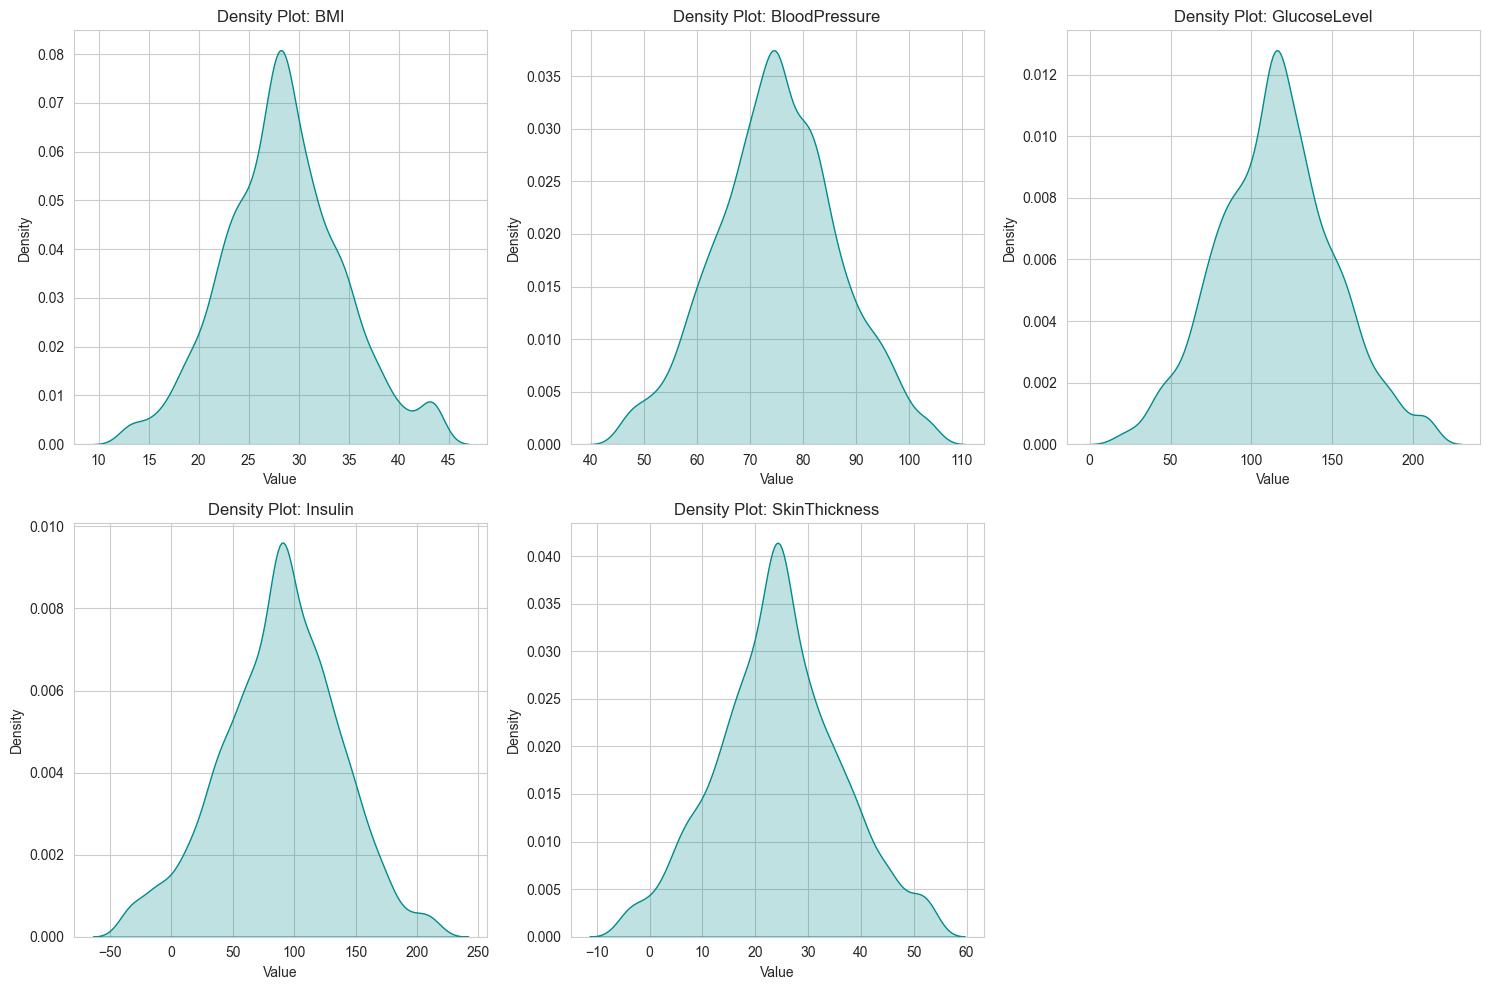

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ['BMI', 'BloodPressure', 'GlucoseLevel', 'Insulin', 'SkinThickness']

sns.set_style("whitegrid")

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)
    # shade=True fills the area under the curve for better visibility
    sns.kdeplot(df[col], fill=True, color="darkcyan", bw_adjust=0.8)
    plt.title(f'Density Plot: {col}')
    plt.xlabel('Value')
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [136]:
print(df.isnull().sum())

PatientID                   0
Age                         0
Gender                      0
BMI                         0
BloodPressure               0
GlucoseLevel                0
Insulin                     0
SkinThickness               0
DiabetesPedigreeFunction    0
PhysicalActivity            0
Smoking                     0
Alcohol_Intake              0
FamilyHistory               0
Outcome                     0
dtype: int64


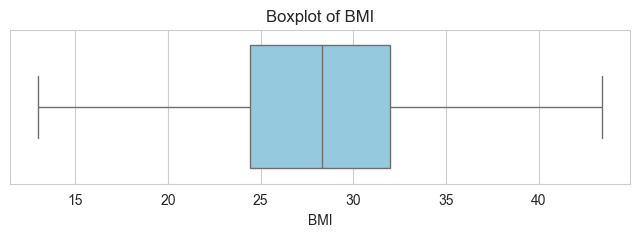

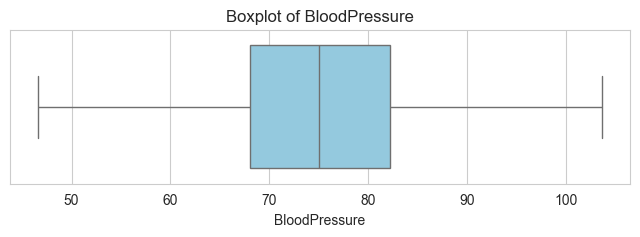

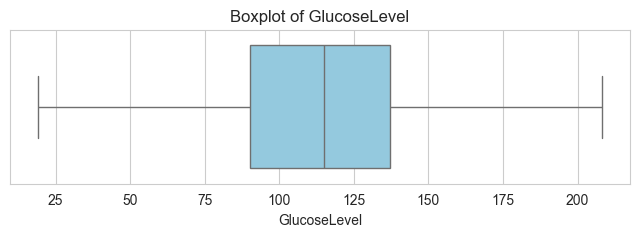

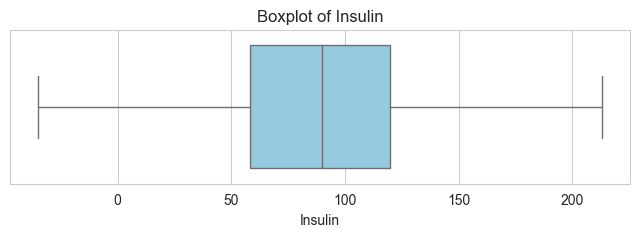

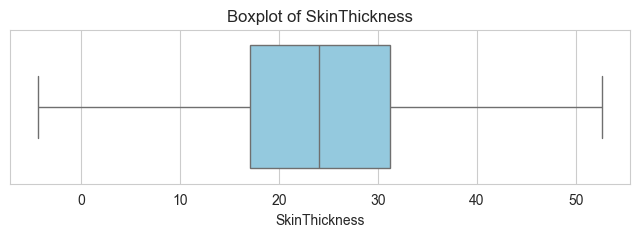

In [137]:
for col in num_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()

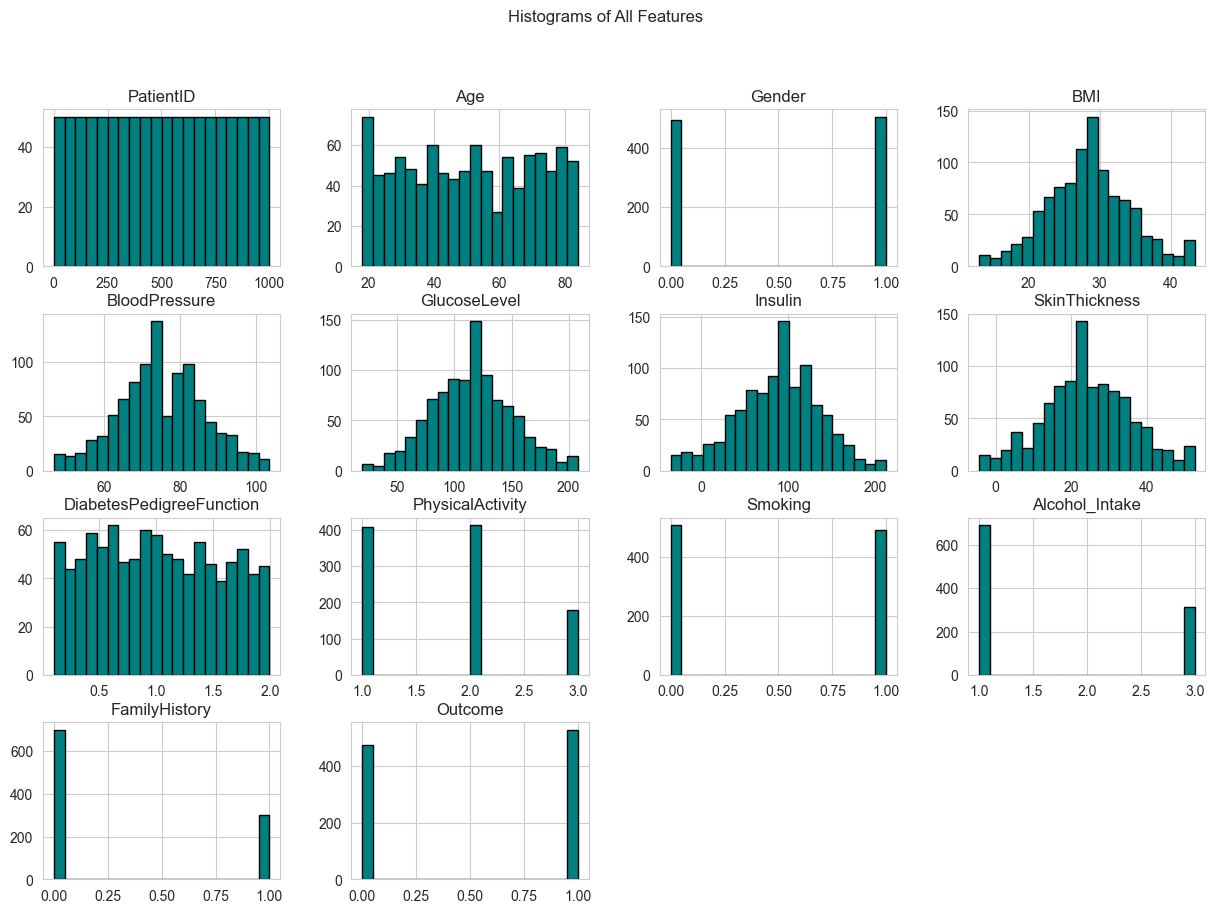

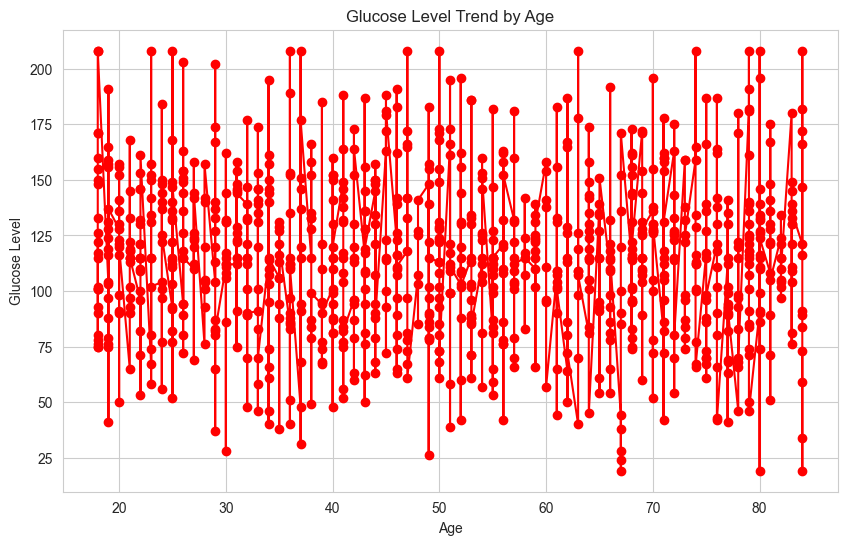

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(15, 10), bins=20, color='teal', edgecolor='black')
plt.suptitle('Histograms of All Features')
plt.show()
df_sorted = df.sort_values('Age')
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['Age'], df_sorted['GlucoseLevel'], marker='o', linestyle='-', color='red')
plt.title('Glucose Level Trend by Age')
plt.xlabel('Age')
plt.ylabel('Glucose Level')
plt.grid(True)
plt.show()

In [139]:
df.to_csv("processed_dataset_new_.csv", index=False)